In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Data Preparation

In [156]:
df = pd.read_csv('mission_launches.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


Fixing the date datatype and spliting date and time

In [158]:
datetime_series = pd.to_datetime(df['Date'], format='mixed', errors='coerce', utc=True)
df['Date'] = datetime_series.dt.date
df['Time'] = datetime_series.dt.time
df

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Time
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,05:12:00
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,04:01:00
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,23:57:00
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,21:25:00
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30,Atlas V 541 | Perseverance,StatusActive,145.0,Success,11:50:00
...,...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05,Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,07:33:00
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01,Juno I | Explorer 1,StatusRetired,NaN,Success,03:48:00
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06,Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,16:44:00
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03,Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,02:30:00


In [159]:
df.isna().sum()/len(df)*100

,0
Unnamed: 0.1,0.000000
Unnamed: 0,0.000000
Organisation,0.000000
Location,0.000000
Date,0.000000
Detail,0.000000
Rocket_Status,0.000000
Price,77.705828
Mission_Status,0.000000
Time,0.000000


We do not know more than 77% of price data, but either deleting the whole column, or changing every NaN value to mean can lead to mistakes in future analysis. For now let's create a new column 'is_price_available'. Using this we can analyse data based on availability of price.

In [160]:
df['is_price_available'] = np.where(df['Price'].isna() == True, 0, 1)
df.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Time,is_price_available
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,05:12:00,1
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,04:01:00,1
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,23:57:00,0
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,21:25:00,1
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30,Atlas V 541 | Perseverance,StatusActive,145.0,Success,11:50:00,1


In [161]:
np.round(df['is_price_available'].value_counts()/len(df)*100, 2)

,count
is_price_available,
0,77.71
1,22.29


#Analysis of number of missions by Organisation

Creating two new DataFrames with division of data based on availability of price

In [162]:
df_with_price = df[df['is_price_available']==1]
df_no_price = df[df['is_price_available']==0]

In [163]:
df_org_num = df_with_price['Organisation'].value_counts()
df_org_no_num = df_no_price['Organisation'].value_counts()

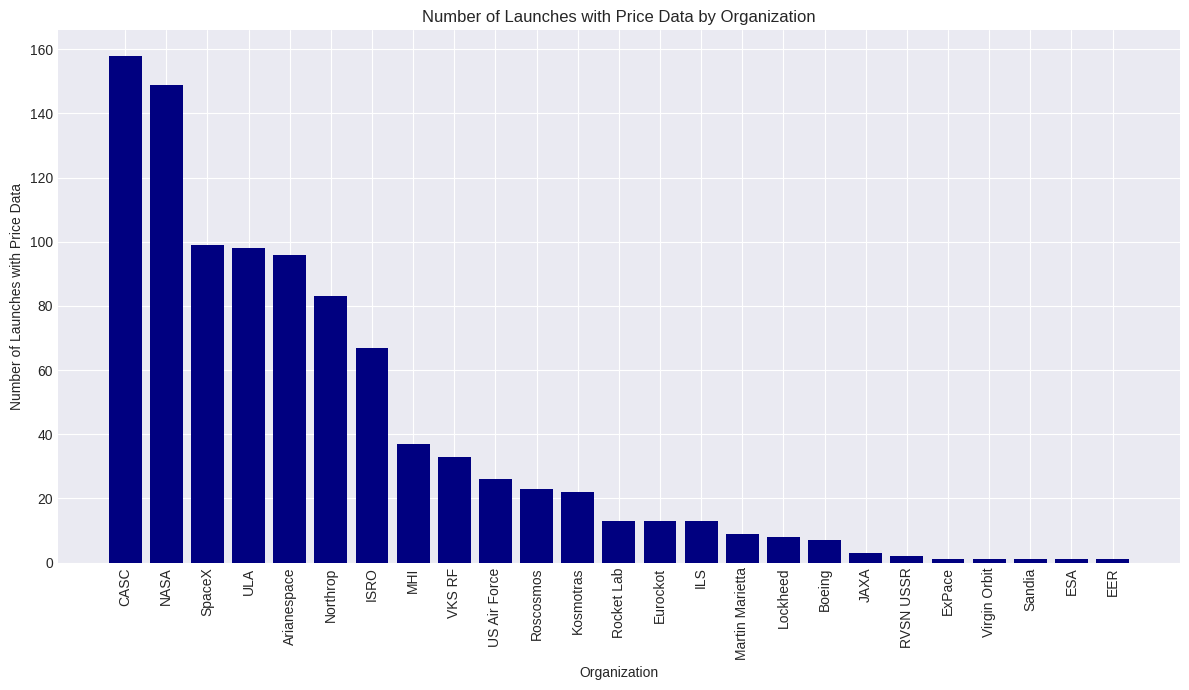

In [164]:
plt.figure(figsize=(12,7))
plt.style.use('seaborn-v0_8-darkgrid')
plt.bar(df_org_num.index, df_org_num.values, color = 'navy')
plt.xlabel('Organization')
plt.ylabel('Number of Launches with Price Data')
plt.title('Number of Launches with Price Data by Organization')
plt.xticks(rotation=90)
plt.tight_layout()

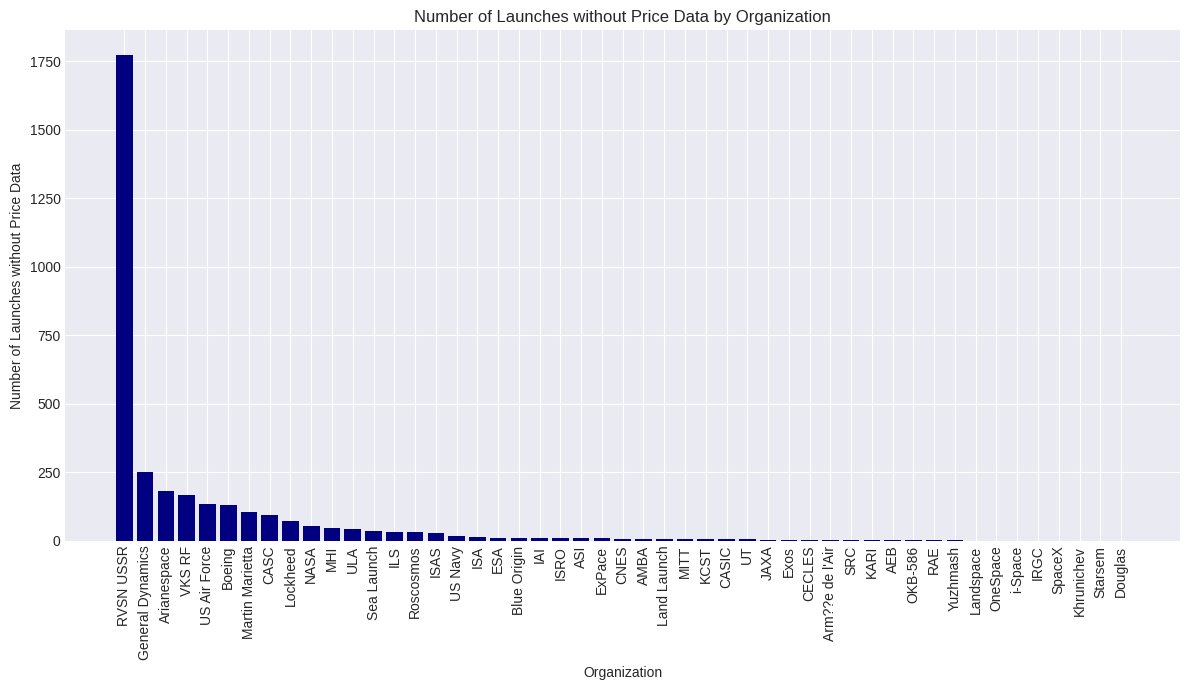

In [165]:
plt.figure(figsize=(12,7))
plt.style.use('seaborn-v0_8-darkgrid')
plt.bar(df_org_no_num.index, df_org_no_num.values, color = 'navy')
plt.xlabel('Organization')
plt.ylabel('Number of Launches without Price Data')
plt.title('Number of Launches without Price Data by Organization')
plt.xticks(rotation=90)
plt.tight_layout()

#Is there a correlation between mission success and price (for missions with price data)?

In [166]:
df_with_price['Mission_Status'].value_counts() #Count of mission status with price information

,count
Mission_Status,
Success,910
Failure,36
Partial Failure,17
Prelaunch Failure,1


In [167]:
df_no_price['Mission_Status'].value_counts() #Count of mission status without price information

,count
Mission_Status,
Success,2969
Failure,303
Partial Failure,85
Prelaunch Failure,3


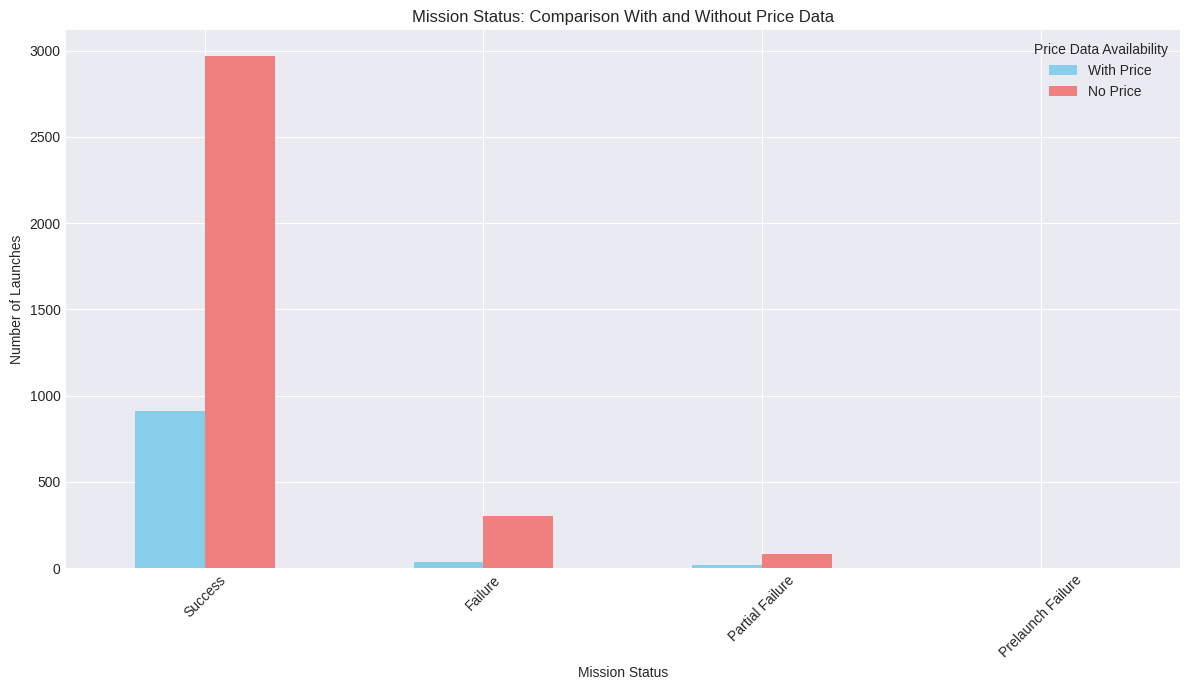

In [168]:
plt.style.use('seaborn-v0_8-darkgrid')

status_with_price = df_with_price['Mission_Status'].value_counts()
status_no_price = df_no_price['Mission_Status'].value_counts()

combined_status = pd.DataFrame({'With Price': status_with_price, 'No Price': status_no_price}).fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
combined_status.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'])

ax.set_title('Mission Status: Comparison With and Without Price Data')
ax.set_xlabel('Mission Status')
ax.set_ylabel('Number of Launches')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Price Data Availability')

plt.tight_layout()

In [169]:
success_percentage_with_price = (combined_status.loc['Success', 'With Price'] / combined_status['With Price'].sum()) * 100
success_percentage_no_price = (combined_status.loc['Success', 'No Price'] / combined_status['No Price'].sum()) * 100

overall_success_missions = df[df['Mission_Status'] == 'Success'].shape[0]
total_missions = df.shape[0]
overall_success_percentage = (overall_success_missions / total_missions) * 100

print(f"Percentage of successful missions with price data: {success_percentage_with_price:.2f}%")
print(f"Percentage of successful missions without price data: {success_percentage_no_price:.2f}%")
print(f"Overall percentage of successful missions: {overall_success_percentage:.2f}%")

Percentage of successful missions with price data: 94.40%
Percentage of successful missions without price data: 88.36%
Overall percentage of successful missions: 89.71%


In [170]:
df_with_price['Price'] = pd.to_numeric(df_with_price['Price'], errors='coerce')

df_with_price['Is_Success'] = (df_with_price['Mission_Status'] == 'Success').astype(int)

correlation = df_with_price['Is_Success'].corr(df_with_price['Price'])

print(f"Correlation between mission success (binary) and price (for missions with price data): {correlation:.4f}")

average_price_successful = df_with_price[df_with_price['Is_Success'] == 1]['Price'].mean()
average_price_unsuccessful = df_with_price[df_with_price['Is_Success'] == 0]['Price'].mean()

print(f"Average price for successful missions: {average_price_successful:.2f}")
print(f"Average price for non-successful missions: {average_price_unsuccessful:.2f}")

Correlation between mission success (binary) and price (for missions with price data): 0.1011
Average price for successful missions: 133.32
Average price for non-successful missions: 70.27


/tmp/ipykernel_10077/3624520947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_price['Price'] = pd.to_numeric(df_with_price['Price'], errors='coerce')
/tmp/ipykernel_10077/3624520947.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_price['Is_Success'] = (df_with_price['Mission_Status'] == 'Success').astype(int)


#What are the earliest and latest missions?

In [171]:
#The earliest mission data
min_date = df['Date'].min()
display(df[df['Date'] == min_date])

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Time,is_price_available
4323,4323,4323,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-10-04,Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success,19:28:00,0


In [172]:
#Latest mission data
max_date = df['Date'].max()
display(df[df['Date'] == max_date])

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Time,is_price_available
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,05:12:00,1


#Hourly number of missions

In [173]:
time_df = df.groupby(df['Time'])['Organisation'].count()
hourly_counts = time_df.groupby(time_df.index.map(lambda t: t.hour)).sum()
hourly_counts

,Organisation
Time,
0,312
1,164
2,114
3,147
4,140
5,148
6,147
7,176
8,194


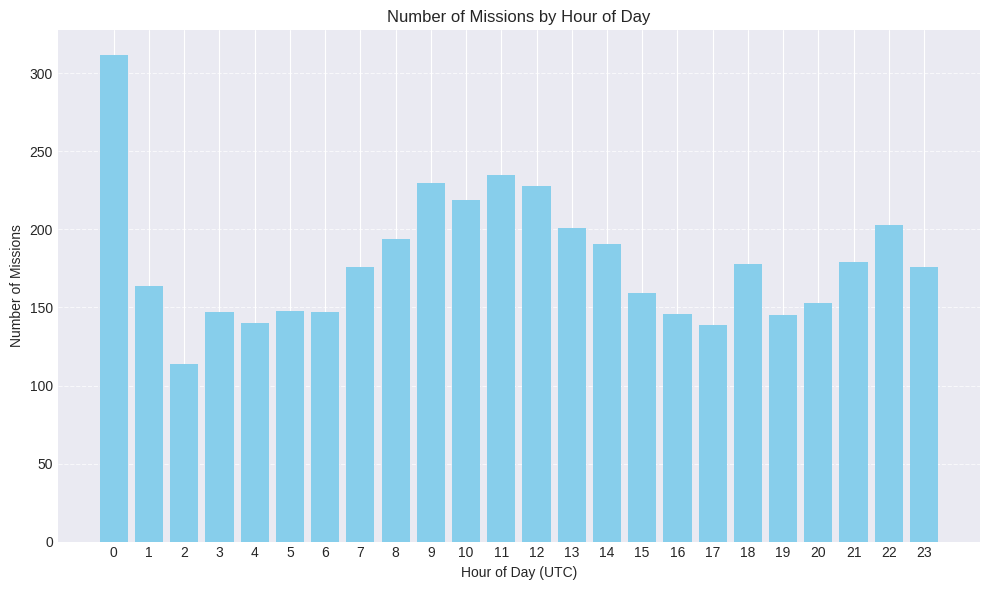

In [174]:
plt.figure(figsize=(10, 6))
plt.bar(hourly_counts.index, hourly_counts.values, color='skyblue')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Number of Missions')
plt.title('Number of Missions by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

#What is the number of Missions per year?

In [175]:
copy_df = df.groupby(df['Date'].apply(lambda x: x.year)).count()
df_year = pd.DataFrame({"Number of Missions": copy_df['Organisation']})
df_year

,Number of Missions
Date,
1957,3
1958,28
1959,20
1960,39
1961,52
...,...
2016,90
2017,92
2018,117


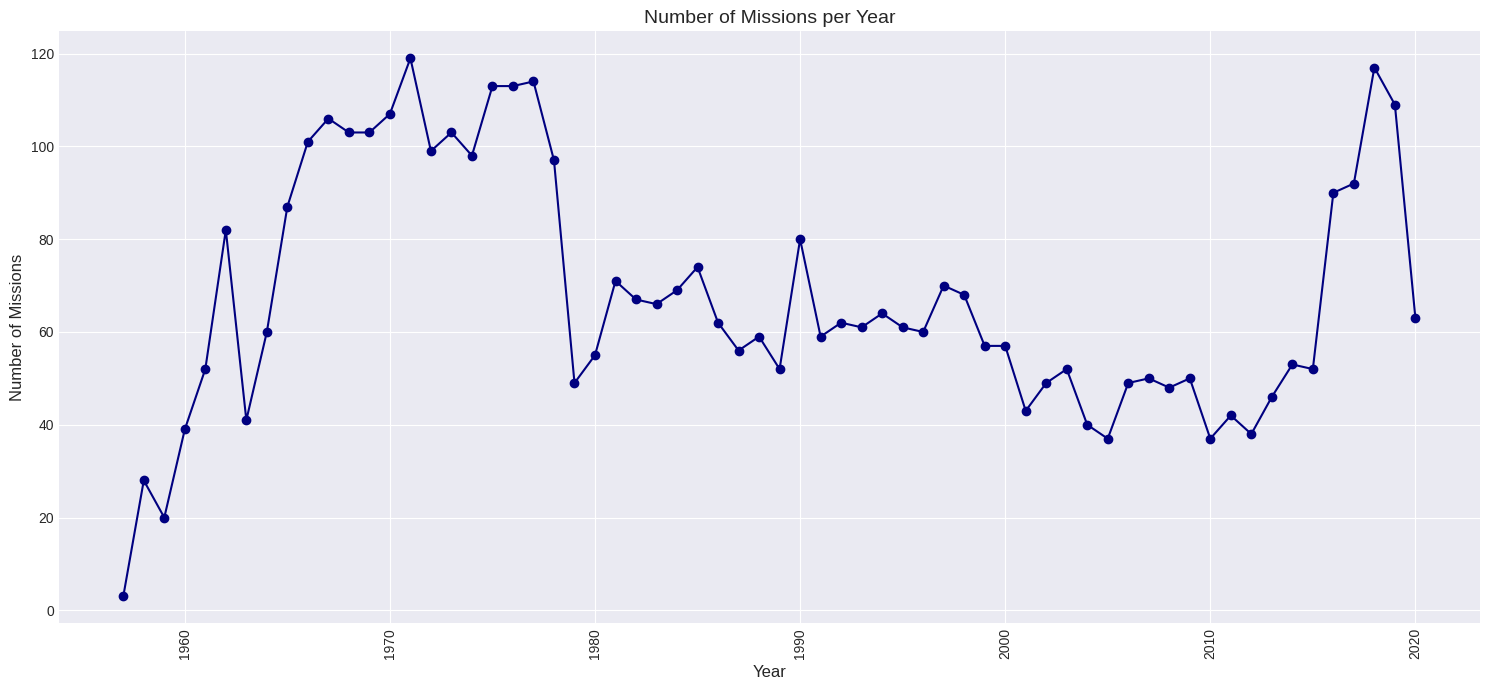

In [176]:
plt.figure(figsize=(15, 7))
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(df_year.index, df_year['Number of Missions'], color='navy', marker='o', linestyle='-')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Missions', fontsize=12)
plt.title('Number of Missions per Year', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.tight_layout()

In [177]:
average_missions_per_year = df_year['Number of Missions'].mean()
print(f"The average number of missions per year is: {average_missions_per_year:.2f}")

The average number of missions per year is: 67.56


#What is the relationship between Data and Price availability?

In [178]:
copy_df_with_price = df_with_price.groupby(df_with_price['Date'].apply(lambda x: x.year)).count()
df_year_with_price = pd.DataFrame({"Number of Prices": copy_df_with_price['Organisation']})
df_year_with_price

,Number of Prices
Date,
1964,2
1965,2
1966,3
1967,8
1968,10
1969,8
1970,1
1971,2
1972,2


In [179]:
copy_df_without_price = df_no_price.groupby(df['Date'].apply(lambda x: x.year)).count()
df_year_without_price = pd.DataFrame({"Number of No Prices": copy_df_without_price['Organisation']})
df_year_without_price

,Number of No Prices
Date,
1957,3
1958,28
1959,20
1960,39
1961,52
...,...
2016,26
2017,26
2018,29


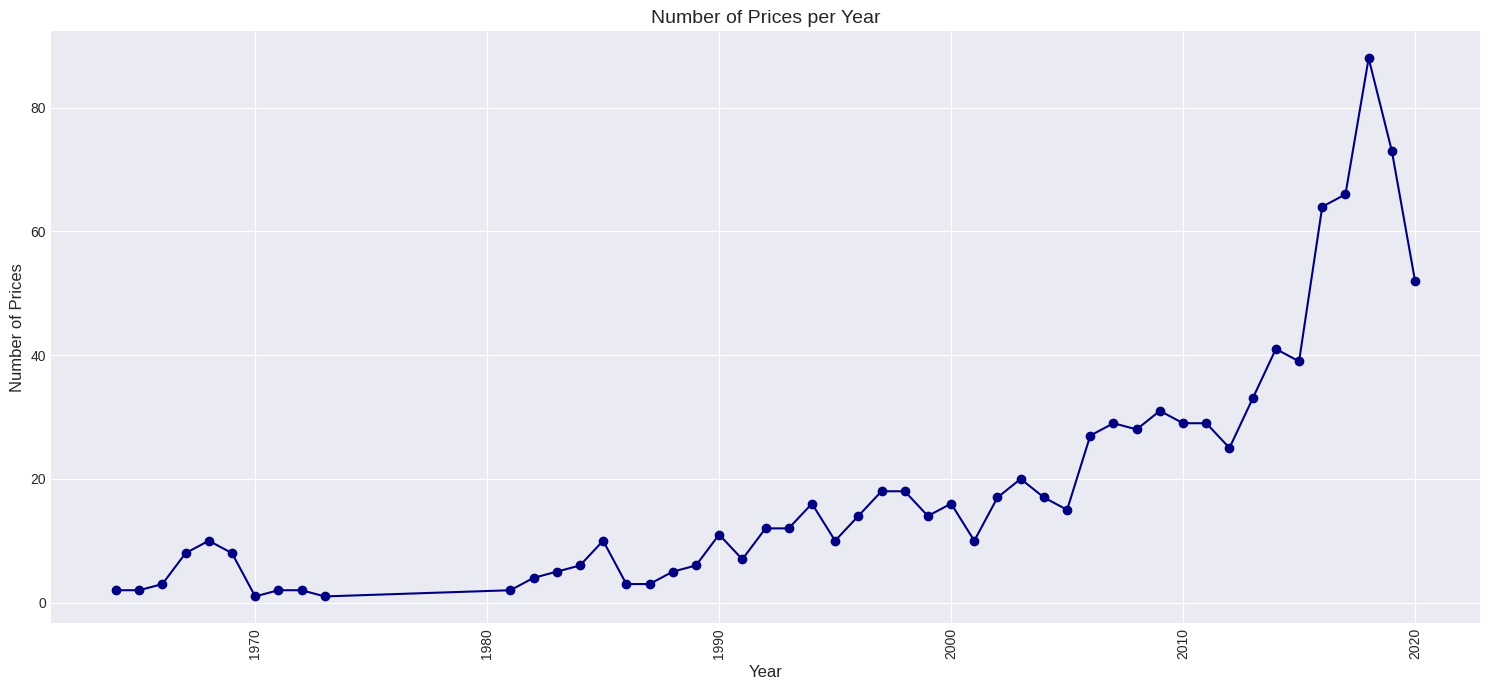

In [180]:
plt.figure(figsize=(15, 7))
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(df_year_with_price.index, df_year_with_price['Number of Prices'], color='navy', marker='o', linestyle='-')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Prices', fontsize=12)
plt.title('Number of Prices per Year', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.tight_layout()

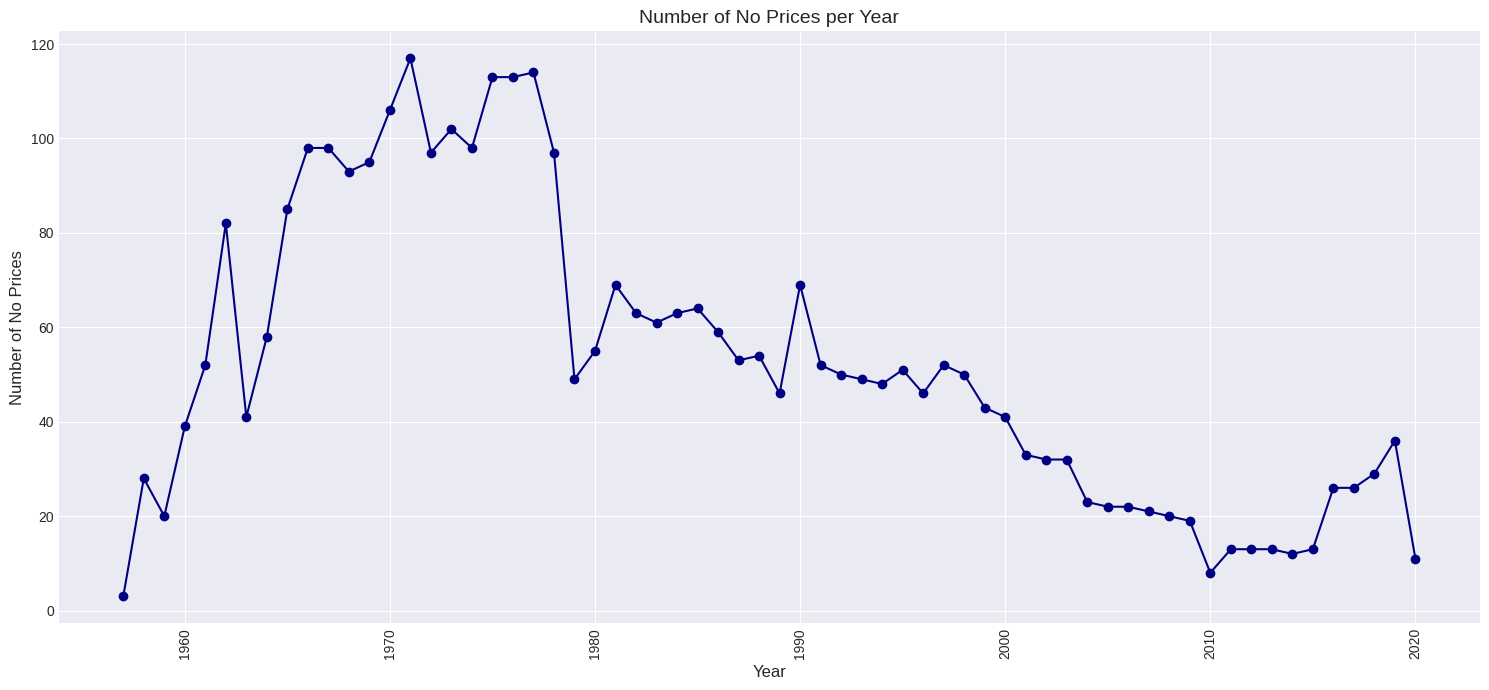

In [181]:
plt.figure(figsize=(15, 7))
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(df_year_without_price.index, df_year_without_price['Number of No Prices'], color='navy', marker='o', linestyle='-')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of No Prices', fontsize=12)
plt.title('Number of No Prices per Year', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.tight_layout()

In [182]:
merged_df_year = pd.merge(df_year_with_price, df_year_without_price, left_index=True, right_index=True, how='outer').fillna(0)
merged_df_year.index.name = 'Year'
merged_df_year['Total Missions'] = merged_df_year['Number of Prices'] + merged_df_year['Number of No Prices']
merged_df_year['Price Availability Ratio'] = merged_df_year['Number of Prices'] / merged_df_year['Total Missions']

display(merged_df_year.head())

,Number of Prices,Number of No Prices,Total Missions,Price Availability Ratio
Year,,,,
1957,0.0,3,3.0,0.0
1958,0.0,28,28.0,0.0
1959,0.0,20,20.0,0.0
1960,0.0,39,39.0,0.0
1961,0.0,52,52.0,0.0


In [183]:
correlation_year_price_ratio = merged_df_year.index.to_series().corr(merged_df_year['Price Availability Ratio'])

print(f"Correlation between Year and Price Availability Ratio: {correlation_year_price_ratio:.4f}")

Correlation between Year and Price Availability Ratio: 0.9030
